<a href="https://colab.research.google.com/github/vikramsingh456/ai-ml/blob/dev/KNNAndDecisionTree.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
precision_score, recall_score, f1_score)

#Load dataset

cancer = load_breast_cancer()

print(cancer.keys())

#Understand the classess
print(cancer.target_names)

#Understand the features
print(cancer.feature_names)

df = pd.DataFrame(cancer['data'], columns=cancer['feature_names'])
df['target'] = cancer['target']

print(df.head())

#Seperate X and y
# X = Feature / Input
# y = Target / Output

X = df.drop('target', axis=1)
y = df['target']


"""
X  is radius, texture, prerimer, area
y = Malignant or Benign

Our Objecective is
Give KNN the tuomor measurment and ask it to predict whether the tumor is Malignant or Benign

"""


#Split the data

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


# Scale the features
#Knn calcualte the distance

# Training - fit and transform
# Testing - Transform

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) #Learn the scaling information from the training data
X_test_scaled = scaler.transform(X_test)


#Create the KNN model

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

#Make predictions
y_pred = knn.predict(X_test_scaled)

#Calcualte Accuracy

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

#Confusion Matrix

confusion = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(confusion)

#Precision, Recall, and F1 Score

#Positive class = 0 = Malignant

precision = precision_score(y_test, y_pred, pos_label=0)
recall = recall_score(y_test, y_pred, pos_label=0)
f1 = f1_score(y_test, y_pred, pos_label=0)

print(f"Precision (Malignant): {precision}")
print(f"Recall (Malignant): {recall}")
print(f"F1 Score (Malignant): {f1}")



# Hyperparameter Tuning - Try Different K values

for k in range(1, 16):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)

    print("K=", k, "Accuracy = ", accuracy)



# Better Hyperparamter Tuning with GridSearchCV

param_grid = {'n_neighbors': [3,5,7,9,11]}
grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train_scaled, y_train)

print("\n --------------- Hyperparamter Tuning ------------")

print("Best K:", grid_search.best_params_)
print("Best Cross Validation Score:", grid_search.best_score_)

# Get the Best Model (Get Best KNN model)

best_knn = grid_search.best_estimator_

# Make Predictions with Best Model

y_pred_best = best_knn.predict(X_test_scaled)

#Final Accuracy

print("Accuracy with Best Model:", accuracy_score(y_test, y_pred_best))











dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])
['malignant' 'benign']
['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        1


 Feature Names:
['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']

 Target Names:
['malignant' 'benign']

 Target:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 0 0 0 0 0 0 0 0 1 0 1 1 1 1 1 0 0 1 0 0 1 1 1 1 0 1 0 0 1 1 1 1 0 1 0 0
 1 0 1 0 0 1 1 1 0 0 1 0 0 0 1 1 1 0 1 1 0 0 1 1 1 0 0 1 1 1 1 0 1 1 0 1 1
 1 1 1 1 1 1 0 0 0 1 0 0 1 1 1 0 0 1 0 1 0 0 1 0 0 1 1 0 1 1 0 1 1 1 1 0 1
 1 1 1 1 1 1 1 1 0 1 1 1 1 0 0 1 0 1 1 0 0 1 1 0 0 1 1 1 1 0 1 1 0 0 0 1 0
 1 0

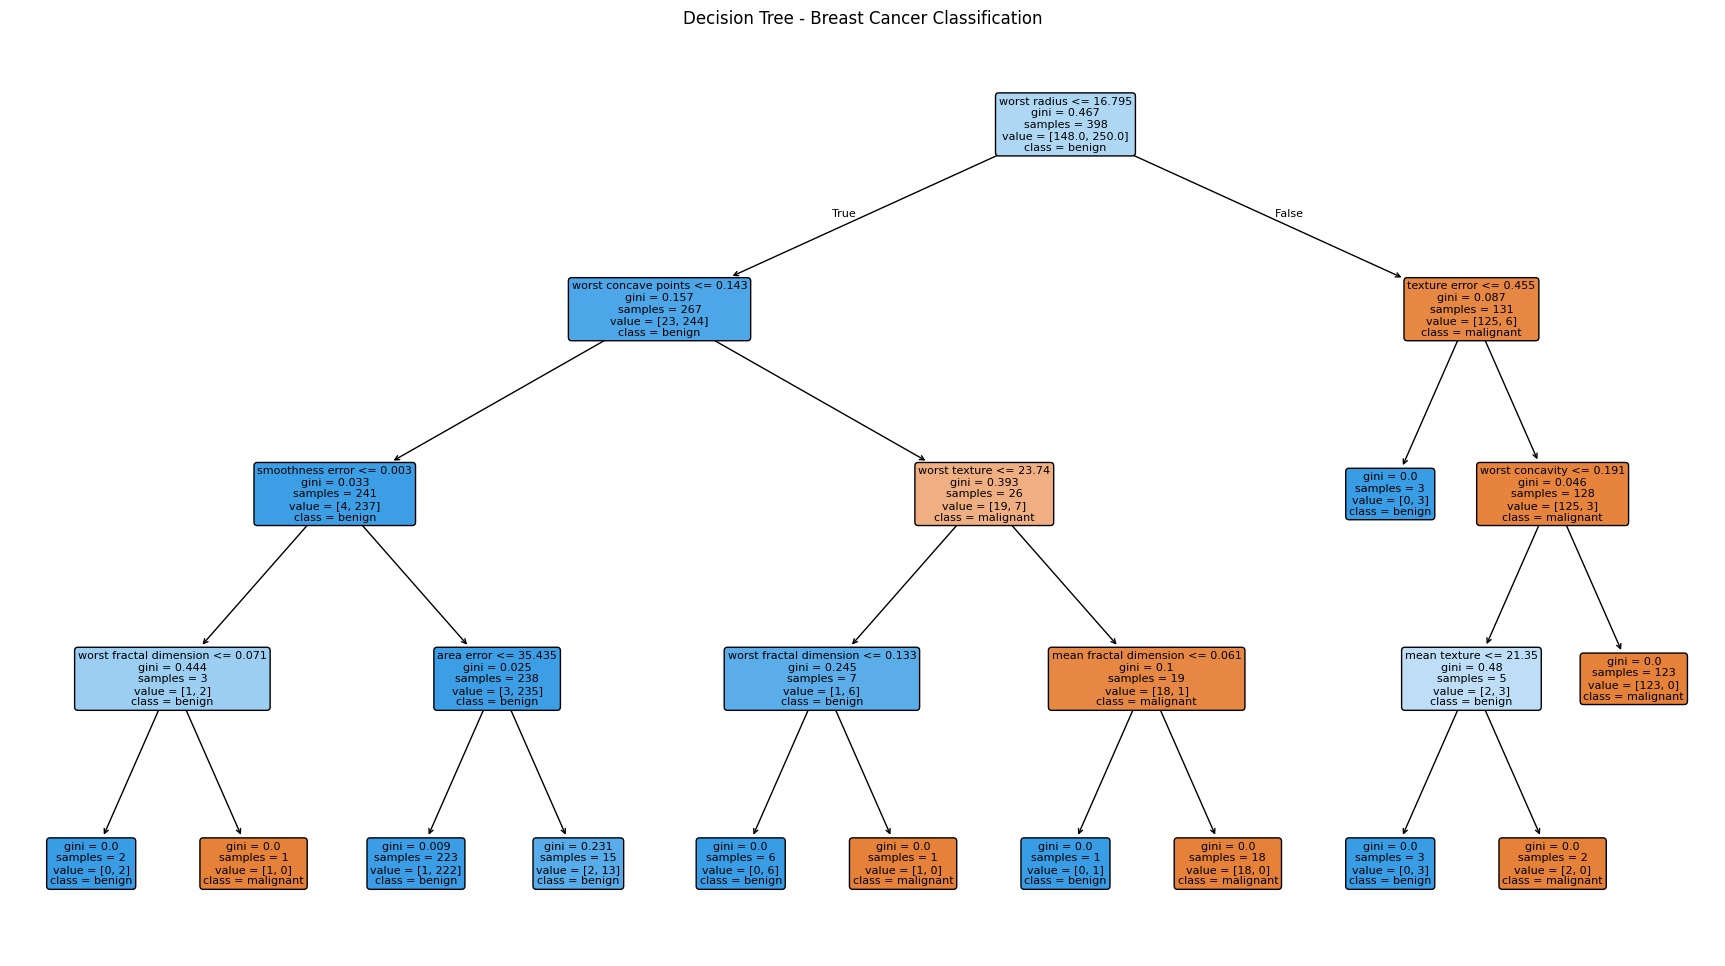


 Feature Importance:
                    Feature  Importance
20             worst radius    0.733864
27     worst concave points    0.132649
21            worst texture    0.036691
11            texture error    0.030980
26          worst concavity    0.019168
29  worst fractal dimension    0.016887
1              mean texture    0.013298
9    mean fractal dimension    0.010499
14         smoothness error    0.003377
13               area error    0.002586
5          mean compactness    0.000000
4           mean smoothness    0.000000
2            mean perimeter    0.000000
0               mean radius    0.000000
12          perimeter error    0.000000
10             radius error    0.000000
7       mean concave points    0.000000
8             mean symmetry    0.000000
6            mean concavity    0.000000
3                 mean area    0.000000
17     concave points error    0.000000
15        compactness error    0.000000
18           symmetry error    0.000000
19  fractal dimens

In [4]:
# DECISION TREE CLASSIFICATION

import pandas as pd
import matplotlib.pyplot as plt


from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
precision_score, recall_score, f1_score)


#Load data
data = load_breast_cancer()

print("\n Feature Names:")
print(data.feature_names)

print("\n Target Names:")
print(data.target_names)

print("\n Target:")
print(data.target)

# conver dataset in dataframe

df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

print("\n First 5 rows:")
print(df.head())

# Seperate X and y
X = df.drop('target', axis=1)
y = df['target']

print("\n Shape of X:", X.shape)
print("Shape of y:", y.shape)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)


print("\n Training samples:", len(X_train))
print("Testing samples:", len(X_test))

# Create the decision tree model

model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=4,
    random_state=42
)

#Train the model
model.fit(X_train, y_train)

print("\n Decision Tree training completed!")

# Make predictions
y_pred = model.predict(X_test)

print("\n First 10 Actual Values:")
print(y_test.values[:10])

print("\n First 10 Predicted Values:")
print(y_pred[:10])


# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print("\n Accuracy:", accuracy)

#Precision
#0= Malignant
# 1= Benign

precision = precision_score(y_test, y_pred, pos_label=0)

print("\n Precision (Malignant)")
print(precision)

recall = recall_score(y_test, y_pred, pos_label=0)
print("\n Recall (Malignant)")
print(recall)

f1 = f1_score(y_test, y_pred, pos_label=0)
print("\n F1 Score (Malignant)")
print(f1)


cm = confusion_matrix(y_test, y_pred)
print("\n Confusion Matrix:")
print(cm)

# Classification Report
print("\n Classification Report:")
print(classification_report(y_test, y_pred, target_names=data.target_names))

# Compare Training and Testing Accuracy

train_accuracy = model.score(X_train, y_train)
test_accuracy = model.score(X_test, y_test)

print("\n Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

# If training accuracy is extremely high but testing accuracy
# is much lower, the tree may be overfitting

# Visulaize the decision tree

plt.figure(figsize=(22, 12))
plot_tree(model, filled=True, feature_names=data.feature_names,
          class_names=data.target_names,

          rounded=True,
          fontsize=8)
plt.title("Decision Tree - Breast Cancer Classification")
plt.show()

# Find Feature Importance

importance = pd.DataFrame({
    "Feature": data.feature_names,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(by="Importance", ascending=False)

print("\n Feature Importance:")
print(importance)

#Display top 10 Importnt Features
print("\n Top 10 Important Features:")
print(importance.head(10))











In [5]:
# ============================================================
# NAIVE BAYES - ONLINE GAMING BEHAVIOR DATASET
# Multiclass Classification
#
# Goal:
# Predict EngagementLevel:
# Low / Medium / High
# ============================================================


# ------------------------------------------------------------
# STEP 1: Import required libraries
# ------------------------------------------------------------

import pandas as pd

# Used to split data into training and testing sets
from sklearn.model_selection import train_test_split

# Used for Naive Bayes classification
from sklearn.naive_bayes import GaussianNB

# Used to evaluate the model
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)


# ------------------------------------------------------------
# STEP 2: Load the dataset
# ------------------------------------------------------------

df = pd.read_csv("/content/online_gaming_behavior_dataset.csv")


# ------------------------------------------------------------
# STEP 3: Look at the dataset
# ------------------------------------------------------------

print("First 5 rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
print(df.info())


# ------------------------------------------------------------
# STEP 4: Check the target classes
# ------------------------------------------------------------

print("\nEngagement Levels:")
print(df["EngagementLevel"].value_counts())


# ------------------------------------------------------------
# STEP 5: Select input features (X) and target (y)
# ------------------------------------------------------------

# X contains the information used for prediction

X = df[[
    "Age",
    "SessionsPerWeek",
    "AvgSessionDurationMinutes",
    "PlayerLevel"
]]

# y contains the value that we want to predict
# Example:
# Low / Medium / High

y = df["EngagementLevel"]


# ------------------------------------------------------------
# STEP 6: Display X and y
# ------------------------------------------------------------

print("\nInput Features (X):")
print(X.head())

print("\nTarget (y):")
print(y.head())


# ------------------------------------------------------------
# STEP 7: Split the dataset
# ------------------------------------------------------------

# 80% data -> Training
# 20% data -> Testing

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining data size:")
print(X_train.shape)

print("\nTesting data size:")
print(X_test.shape)


# ------------------------------------------------------------
# STEP 8: Create the Naive Bayes model
# ------------------------------------------------------------

# GaussianNB is suitable when our input features
# are numerical values.

model = GaussianNB()


# ------------------------------------------------------------
# STEP 9: Train the model
# ------------------------------------------------------------

model.fit(X_train, y_train)

print("\nNaive Bayes model trained successfully.")


# ------------------------------------------------------------
# STEP 10: Make predictions
# ------------------------------------------------------------

y_pred = model.predict(X_test)

print("\nPredicted Values:")
print(y_pred[:20])

print("\nActual Values:")
print(y_test.values[:20])


# ------------------------------------------------------------
# STEP 11: Calculate Accuracy
# ------------------------------------------------------------

accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:")
print(accuracy)

print("\nAccuracy Percentage:")
print(f"{accuracy * 100:.2f}%")


# ------------------------------------------------------------
# STEP 12: Confusion Matrix
# ------------------------------------------------------------

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)


# ------------------------------------------------------------
# STEP 13: Classification Report
# ------------------------------------------------------------

# Shows:
# Precision
# Recall
# F1-score
# for Low, Medium and High separately

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


# ------------------------------------------------------------
# STEP 14: Compare Actual and Predicted values
# ------------------------------------------------------------

results = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

print("\nActual vs Predicted:")
print(results.head(20))


# ------------------------------------------------------------
# STEP 15: Predict Engagement Level for a new player
# ------------------------------------------------------------

# Example new player:
#
# Age = 25
# SessionsPerWeek = 15
# AvgSessionDurationMinutes = 100
# PlayerLevel = 45

new_player = pd.DataFrame({
    "Age": [25],
    "SessionsPerWeek": [15],
    "AvgSessionDurationMinutes": [100],
    "PlayerLevel": [45]
})


# Predict the engagement level

prediction = model.predict(new_player)

print("\nNew Player Prediction:")
print(prediction[0])


# ------------------------------------------------------------
# STEP 16: Show probabilities for each class
# ------------------------------------------------------------

probabilities = model.predict_proba(new_player)

print("\nClasses:")
print(model.classes_)

print("\nProbability for each class:")
print(probabilities)


# Display probabilities in a clearer format

probability_table = pd.DataFrame(
    probabilities,
    columns=model.classes_
)

print("\nProbability Table:")
print(probability_table)

First 5 rows:
   PlayerID  Age  Gender Location GameGenre  PlayTimeHours  InGamePurchases  \
0      9000   43    Male    Other  Strategy      16.271119                0   
1      9001   29  Female      USA  Strategy       5.525961                0   
2      9002   22  Female      USA    Sports       8.223755                0   
3      9003   35    Male      USA    Action       5.265351                1   
4      9004   33    Male   Europe    Action      15.531945                0   

  GameDifficulty  SessionsPerWeek  AvgSessionDurationMinutes  PlayerLevel  \
0         Medium                6                        108           79   
1         Medium                5                        144           11   
2           Easy               16                        142           35   
3           Easy                9                         85           57   
4         Medium                2                        131           95   

   AchievementsUnlocked EngagementLevel  
0     